<a href="https://colab.research.google.com/github/varun0852/ML-PROJECTS/blob/main/Spam_Detection_using_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import nltk

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dev\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

In [ ]:
df = pd.read_csv(r"spam.csv", encoding="cp1252")
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df1 = df[["v1", "v2"]]
df1

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<Axes: xlabel='v1', ylabel='count'>

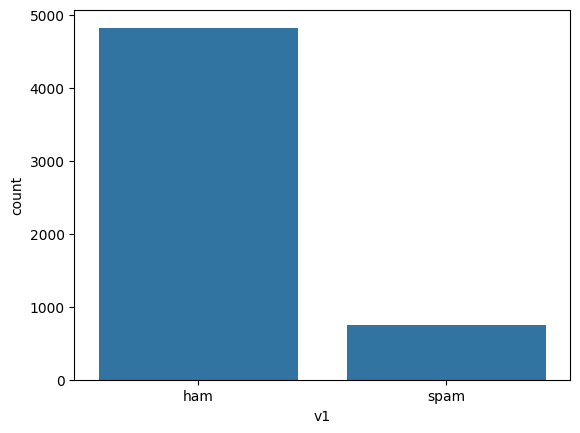

In [ ]:
sns.countplot(data=df, x='v1')

In [ ]:
lemmatizer = WordNetLemmatizer()
df1['v2'][1]
r = re.sub('[^a-zA-Z]', ' ',df1["v2"][4])
r = r.lower()
r = r.split()
r = [word for word in r if word not in stopwords.words('english')]
r = [lemmatizer.lemmatize(word) for word in r]
r = ' '.join(r)
print(r)

nah think go usf life around though


In [ ]:
corpus = []
lemmatizer = WordNetLemmatizer()
for i in range(len(df1["v2"])):
    r = re.sub('[^a-zA-Z]', ' ',df1["v2"][i])
    r = r.lower()
    r = r.split()
    r = [word for word in r if word not in stopwords.words('english')]
    r = [lemmatizer.lemmatize(word) for word in r]
    r = ' '.join(r)
    corpus.append(r)

In [ ]:
df1["text"] = corpus

C:\Users\Dev\AppData\Local\Temp\ipykernel_22060\876711932.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["text"] = corpus


In [ ]:
df1

,v1,v2,text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,nd time tried contact u u pound prize claim ea...
5568,ham,Will Ì_ b going to esplanade fr home?,b going esplanade fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood suggestion
5570,ham,The guy did some bitching but I acted like i'd...,guy bitching acted like interested buying some...


In [ ]:
print(df1["v2"][10])
print(df1["text"][10])

I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
gonna home soon want talk stuff anymore tonight k cried enough today


In [ ]:
x = df1["text"]
y = df1["v1"]
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=7)

In [ ]:
xtrain

4459    wishing great day moji told offer always speec...
1921                              current food alone also
5255                                       ok sweet dream
5507                              want inside every night
356     congratulation ur awarded cd voucher gift guar...
                              ...                        
4307                      ha ha popped loo hello ed hello
2550               please sen kind advice please come try
537                    maybe fat finger press button know
1220    nokia tone ur mob every week txt nok st tone f...
4271                                                  get
Name: text, Length: 4457, dtype: object

In [ ]:
count_vectorizer = CountVectorizer()
xtrain_bow = count_vectorizer.fit_transform(xtrain)

In [ ]:
xtrain_bow

<4457x6289 sparse matrix of type '<class 'numpy.int64'>'
	with 35889 stored elements in Compressed Sparse Row format>

In [ ]:
lr = LogisticRegression()
lr.fit(xtrain_bow, ytrain)

LogisticRegression()

In [ ]:
xtest_bow = count_vectorizer.transform(xtest)
y_pred = lr.predict(xtest_bow)
print(y_pred)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [ ]:
confusion_matrix(ytest, y_pred)

array([[969,   1],
       [ 15, 130]], dtype=int64)

In [ ]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       970
        spam       0.99      0.90      0.94       145

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



In [ ]:
count_vectorizer = CountVectorizer()
x_bow = count_vectorizer.fit_transform(x)

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(x_bow, y, test_size=0.2, random_state=7)

In [ ]:
nb = MultinomialNB()
nb.fit(xtrain.toarray(), ytrain)

MultinomialNB()

In [ ]:
y_pred = nb.predict(xtest.toarray())
print(y_pred)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [ ]:
confusion_matrix(ytest, y_pred)

array([[953,  17],
       [  6, 139]], dtype=int64)

In [ ]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       970
        spam       0.89      0.96      0.92       145

    accuracy                           0.98      1115
   macro avg       0.94      0.97      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
count_vectorizer = CountVectorizer()
x_bow = count_vectorizer.fit_transform(x)
xtrain, xtest, ytrain, ytest = train_test_split(x_bow, y, test_size=0.2, random_state=7)

In [ ]:
svc = SVC()
svc.fit(xtrain.toarray(), ytrain)

SVC()

In [ ]:
y_pred = svc.predict(xtest.toarray())
print(y_pred)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [ ]:
confusion_matrix(ytest, y_pred)

array([[969,   1],
       [ 21, 124]], dtype=int64)

In [ ]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       970
        spam       0.99      0.86      0.92       145

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [ ]:
tfidf_vectorizer = TfidfVectorizer()
xtrain_tfidf = tfidf_vectorizer.fit_transform(xtrain)

In [ ]:
lr = LogisticRegression()
lr.fit(xtrain_tfidf, ytrain)

LogisticRegression()

In [ ]:
xtest_bow = tfidf_vectorizer.transform(xtest)
y_pred = lr.predict(xtest_bow)
print(y_pred)

['ham' 'ham' 'ham' ... 'ham' 'ham' 'ham']


In [ ]:
confusion_matrix(ytest, y_pred)

array([[967,   3],
       [ 35, 110]], dtype=int64)

In [ ]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       970
        spam       0.97      0.76      0.85       145

    accuracy                           0.97      1115
   macro avg       0.97      0.88      0.92      1115
weighted avg       0.97      0.97      0.96      1115

